In [1]:
import pandas as pd 

df = pd.read_csv('ham10000/HAM10000_metadata.csv')
df.head()

,lesion_id,image_id,dx,dx_type,age,sex,localization
0,HAM_0000118,ISIC_0027419,bkl,histo,80.0,male,scalp
1,HAM_0000118,ISIC_0025030,bkl,histo,80.0,male,scalp
2,HAM_0002730,ISIC_0026769,bkl,histo,80.0,male,scalp
3,HAM_0002730,ISIC_0025661,bkl,histo,80.0,male,scalp
4,HAM_0001466,ISIC_0031633,bkl,histo,75.0,male,ear


In [3]:
import os
import pandas as pd
from glob import glob


dataset_path = "ham10000"
csv_path = os.path.join(dataset_path, "HAM10000_metadata.csv")
image_dir_1 = os.path.join(dataset_path, "HAM10000_images_part_1")
image_dir_2 = os.path.join(dataset_path, "HAM10000_images_part_2")


df = pd.read_csv(csv_path)


all_image_paths = glob(os.path.join(image_dir_1, '*.jpg')) + glob(os.path.join(image_dir_2, '*.jpg'))


imageid_path_dict = {
    os.path.splitext(os.path.basename(path))[0]: path
    for path in all_image_paths
}


df['image_path'] = df['image_id'].map(imageid_path_dict)


df = df[df['image_path'].notnull()]

print(f" Combined dataset shape: {df.shape}")
print(df[['image_id', 'image_path']].head())


 Combined dataset shape: (10015, 8)
       image_id                                        image_path
0  ISIC_0027419  ham10000/HAM10000_images_part_1/ISIC_0027419.jpg
1  ISIC_0025030  ham10000/HAM10000_images_part_1/ISIC_0025030.jpg
2  ISIC_0026769  ham10000/HAM10000_images_part_1/ISIC_0026769.jpg
3  ISIC_0025661  ham10000/HAM10000_images_part_1/ISIC_0025661.jpg
4  ISIC_0031633  ham10000/HAM10000_images_part_2/ISIC_0031633.jpg


In [4]:
print(f" Total entries in df: {df.shape[0]}")
print(f" Columns in df: {df.shape[1]}")


 Total entries in df: 10015
 Columns in df: 8


In [5]:
print("Image count per original class (dx):")
print(df['dx'].value_counts())


Image count per original class (dx):
dx
nv       6705
mel      1113
bkl      1099
bcc       514
akiec     327
vasc      142
df        115
Name: count, dtype: int64


In [6]:
#Removing duplicates
df_unique = df.drop_duplicates(subset='lesion_id')


print(f"Original dataset size: {df.shape[0]}")
print(f"After duplicate removal: {df_unique.shape[0]}")


Original dataset size: 10015
After duplicate removal: 7470


In [7]:
from sklearn.preprocessing import LabelEncoder


le = LabelEncoder()
df['label'] = le.fit_transform(df['dx'])


print("Encoded class labels:", dict(zip(le.classes_, range(len(le.classes_)))))


Encoded class labels: {'akiec': 0, 'bcc': 1, 'bkl': 2, 'df': 3, 'mel': 4, 'nv': 5, 'vasc': 6}


In [8]:
from sklearn.model_selection import train_test_split


df_unique = df.drop_duplicates(subset='lesion_id')
print(f"Deduplicated dataset size: {df_unique.shape[0]}")

# Splitting dataset into 80% train and 20% test
train_val_df, test_df = train_test_split(
    df_unique,
    test_size=0.20,
    stratify=df_unique['dx'],
    random_state=42
)

# Step 3: Splitting train dataset into 80% train and 20% validation. This gives us a overall split of 64:16:20 train, val, test split
train_df, val_df = train_test_split(
    train_val_df,
    test_size=0.20,  
    stratify=train_val_df['dx'],
    random_state=42
)

# Step 4: Print final sizes and class distributions
print(f"\nTrain set: {len(train_df)}")
print(f"Validation set: {len(val_df)}")
print(f"Test set: {len(test_df)}")

print("\nTrain class distribution:\n", train_df['dx'].value_counts())
print("\nValidation class distribution:\n", val_df['dx'].value_counts())
print("\nTest class distribution:\n", test_df['dx'].value_counts())


Deduplicated dataset size: 7470

Train set: 4780
Validation set: 1196
Test set: 1494

Train class distribution:
 dx
nv       3458
bkl       465
mel       393
bcc       210
akiec     146
vasc       62
df         46
Name: count, dtype: int64

Validation class distribution:
 dx
nv       865
bkl      117
mel       98
bcc       52
akiec     36
vasc      16
df        12
Name: count, dtype: int64

Test class distribution:
 dx
nv       1080
bkl       145
mel       123
bcc        65
akiec      46
vasc       20
df         15
Name: count, dtype: int64


In [9]:
import tensorflow as tf
from tensorflow.keras.applications import Xception
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Input
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.preprocessing.image import ImageDataGenerator


2025-05-04 20:15:57.083674: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2025-05-04 20:15:57.083750: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2025-05-04 20:15:57.145037: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-05-04 20:15:57.257245: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: SSE4.1 SSE4.2 AVX AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [10]:
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report
from tensorflow.keras.applications import Xception
from tensorflow.keras.models import Model, load_model
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization, GlobalAveragePooling2D, Input
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping
from tensorflow.keras.optimizers import Adam


INPUT_SHAPE = (299, 299, 3)
BATCH_SIZE = 32
EPOCHS = 30
NUM_CLASSES = len(df['label'].unique())




train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=30,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.2,
    horizontal_flip=True,
    vertical_flip=True
)

val_test_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_dataframe(
    dataframe=train_df,
    x_col='image_path',
    y_col='dx',
    target_size=INPUT_SHAPE[:2],
    batch_size=BATCH_SIZE,
    class_mode='sparse',
    shuffle=True,
    seed=42
)

val_generator = val_test_datagen.flow_from_dataframe(
    dataframe=val_df,
    x_col='image_path',
    y_col='dx',
    target_size=INPUT_SHAPE[:2],
    batch_size=BATCH_SIZE,
    class_mode='sparse',
    shuffle=False,
    seed=42
)

test_generator = val_test_datagen.flow_from_dataframe(
    dataframe=test_df,
    x_col='image_path',
    y_col='dx',
    target_size=INPUT_SHAPE[:2],
    batch_size=BATCH_SIZE,
    class_mode='sparse',
    shuffle=False,
    seed=42
)









Found 4780 validated image filenames belonging to 7 classes.
Found 1196 validated image filenames belonging to 7 classes.
Found 1494 validated image filenames belonging to 7 classes.


In [18]:
from tensorflow.keras.applications import InceptionResNetV2
def inceptionresnet_model(input_shape=(299, 299, 3), num_classes=7):
    base_model = InceptionResNetV2(weights='imagenet', include_top=False, input_tensor=Input(shape=input_shape))
    x = base_model.output
    x = GlobalAveragePooling2D()(x)
    x = BatchNormalization()(x)
    x = Dropout(0.5)(x)
    x = Dense(512, activation='relu')(x)
    x = BatchNormalization()(x)
    x = Dropout(0.3)(x)
    outputs = Dense(num_classes, activation='softmax')(x)
    model = Model(inputs=base_model.input, outputs=outputs)
    model.compile(optimizer=Adam(1e-4), loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    return model


In [19]:
# Callbacks for InceptionResNetV2 model
checkpoint = ModelCheckpoint("inceptionresnet_best_model_final1.h5", monitor='val_accuracy', save_best_only=True, verbose=1)
early_stop = EarlyStopping(monitor='val_accuracy', patience=7, restore_best_weights=True, verbose=1)

# Build and train the model
model = inceptionresnet_model(INPUT_SHAPE, NUM_CLASSES)
history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=EPOCHS,
    callbacks=[checkpoint, early_stop]
)


219055592/219055592 [==============================] - 4s 0us/step
Epoch 1/30
150/150 [==============================] - ETA: 0s - loss: 1.7080 - accuracy: 0.5596
Epoch 1: val_accuracy improved from -inf to 0.62375, saving model to inceptionresnet_best_model_final1.h5


/packages/envs/tensorflow-gpu-2.15.0/lib/python3.11/site-packages/keras/src/engine/training.py:3103: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


150/150 [==============================] - 143s 579ms/step - loss: 1.7080 - accuracy: 0.5596 - val_loss: 1.6717 - val_accuracy: 0.6237
Epoch 2/30
150/150 [==============================] - ETA: 0s - loss: 1.0306 - accuracy: 0.7548
Epoch 2: val_accuracy improved from 0.62375 to 0.74749, saving model to inceptionresnet_best_model_final1.h5
150/150 [==============================] - 81s 537ms/step - loss: 1.0306 - accuracy: 0.7548 - val_loss: 1.1502 - val_accuracy: 0.7475
Epoch 3/30
150/150 [==============================] - ETA: 0s - loss: 0.8017 - accuracy: 0.7887
Epoch 3: val_accuracy improved from 0.74749 to 0.77926, saving model to inceptionresnet_best_model_final1.h5
150/150 [==============================] - 81s 539ms/step - loss: 0.8017 - accuracy: 0.7887 - val_loss: 1.4698 - val_accuracy: 0.7793
Epoch 4/30
150/150 [==============================] - ETA: 0s - loss: 0.7756 - accuracy: 0.7998
Epoch 4: val_accuracy improved from 0.77926 to 0.80518, saving model to inceptionresnet_bes

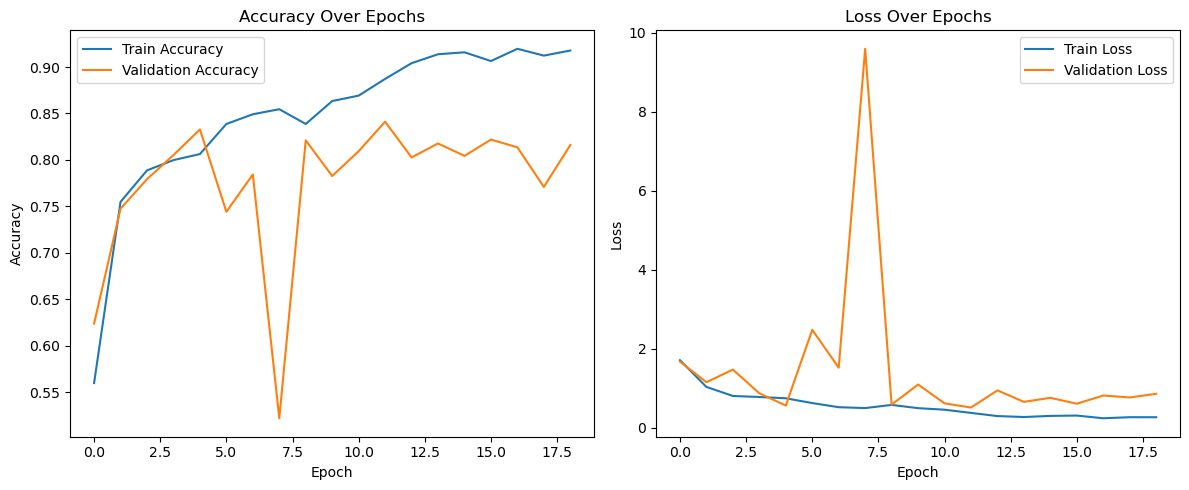

In [24]:
# Plot training history
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Accuracy Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Loss Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()

47/47 [==============================] - 10s 182ms/step


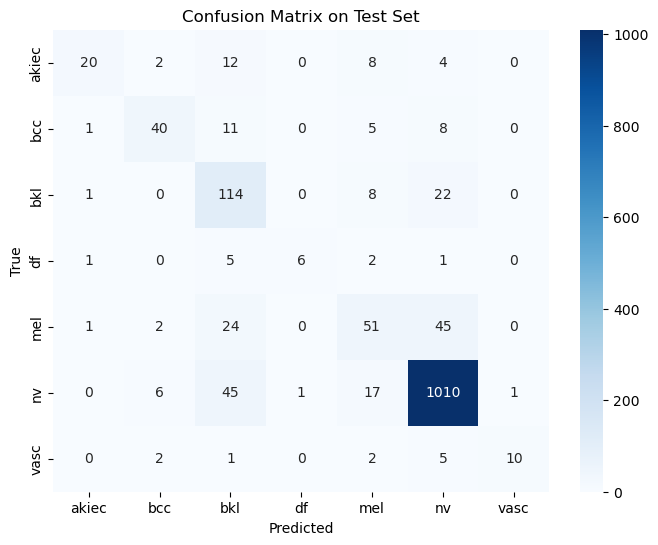

              precision    recall  f1-score   support

       akiec       0.83      0.43      0.57        46
         bcc       0.77      0.62      0.68        65
         bkl       0.54      0.79      0.64       145
          df       0.86      0.40      0.55        15
         mel       0.55      0.41      0.47       123
          nv       0.92      0.94      0.93      1080
        vasc       0.91      0.50      0.65        20

    accuracy                           0.84      1494
   macro avg       0.77      0.58      0.64      1494
weighted avg       0.84      0.84      0.83      1494



In [25]:
# Loading best model
best_model = load_model("inceptionresnet_best_model_final1.h5")

# Evaluating on test set
test_steps = test_generator.samples // test_generator.batch_size + 1
y_pred_probs = best_model.predict(test_generator, steps=test_steps)
y_pred = np.argmax(y_pred_probs, axis=1)
y_true = test_generator.classes

# Confusion Matrix
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix on Test Set')
plt.show()

# Classification Report
print(classification_report(y_true, y_pred, target_names=le.classes_))

In [26]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_true, y_pred)
print(f"Accuracy: {accuracy:.4f}")


Accuracy: 0.8373


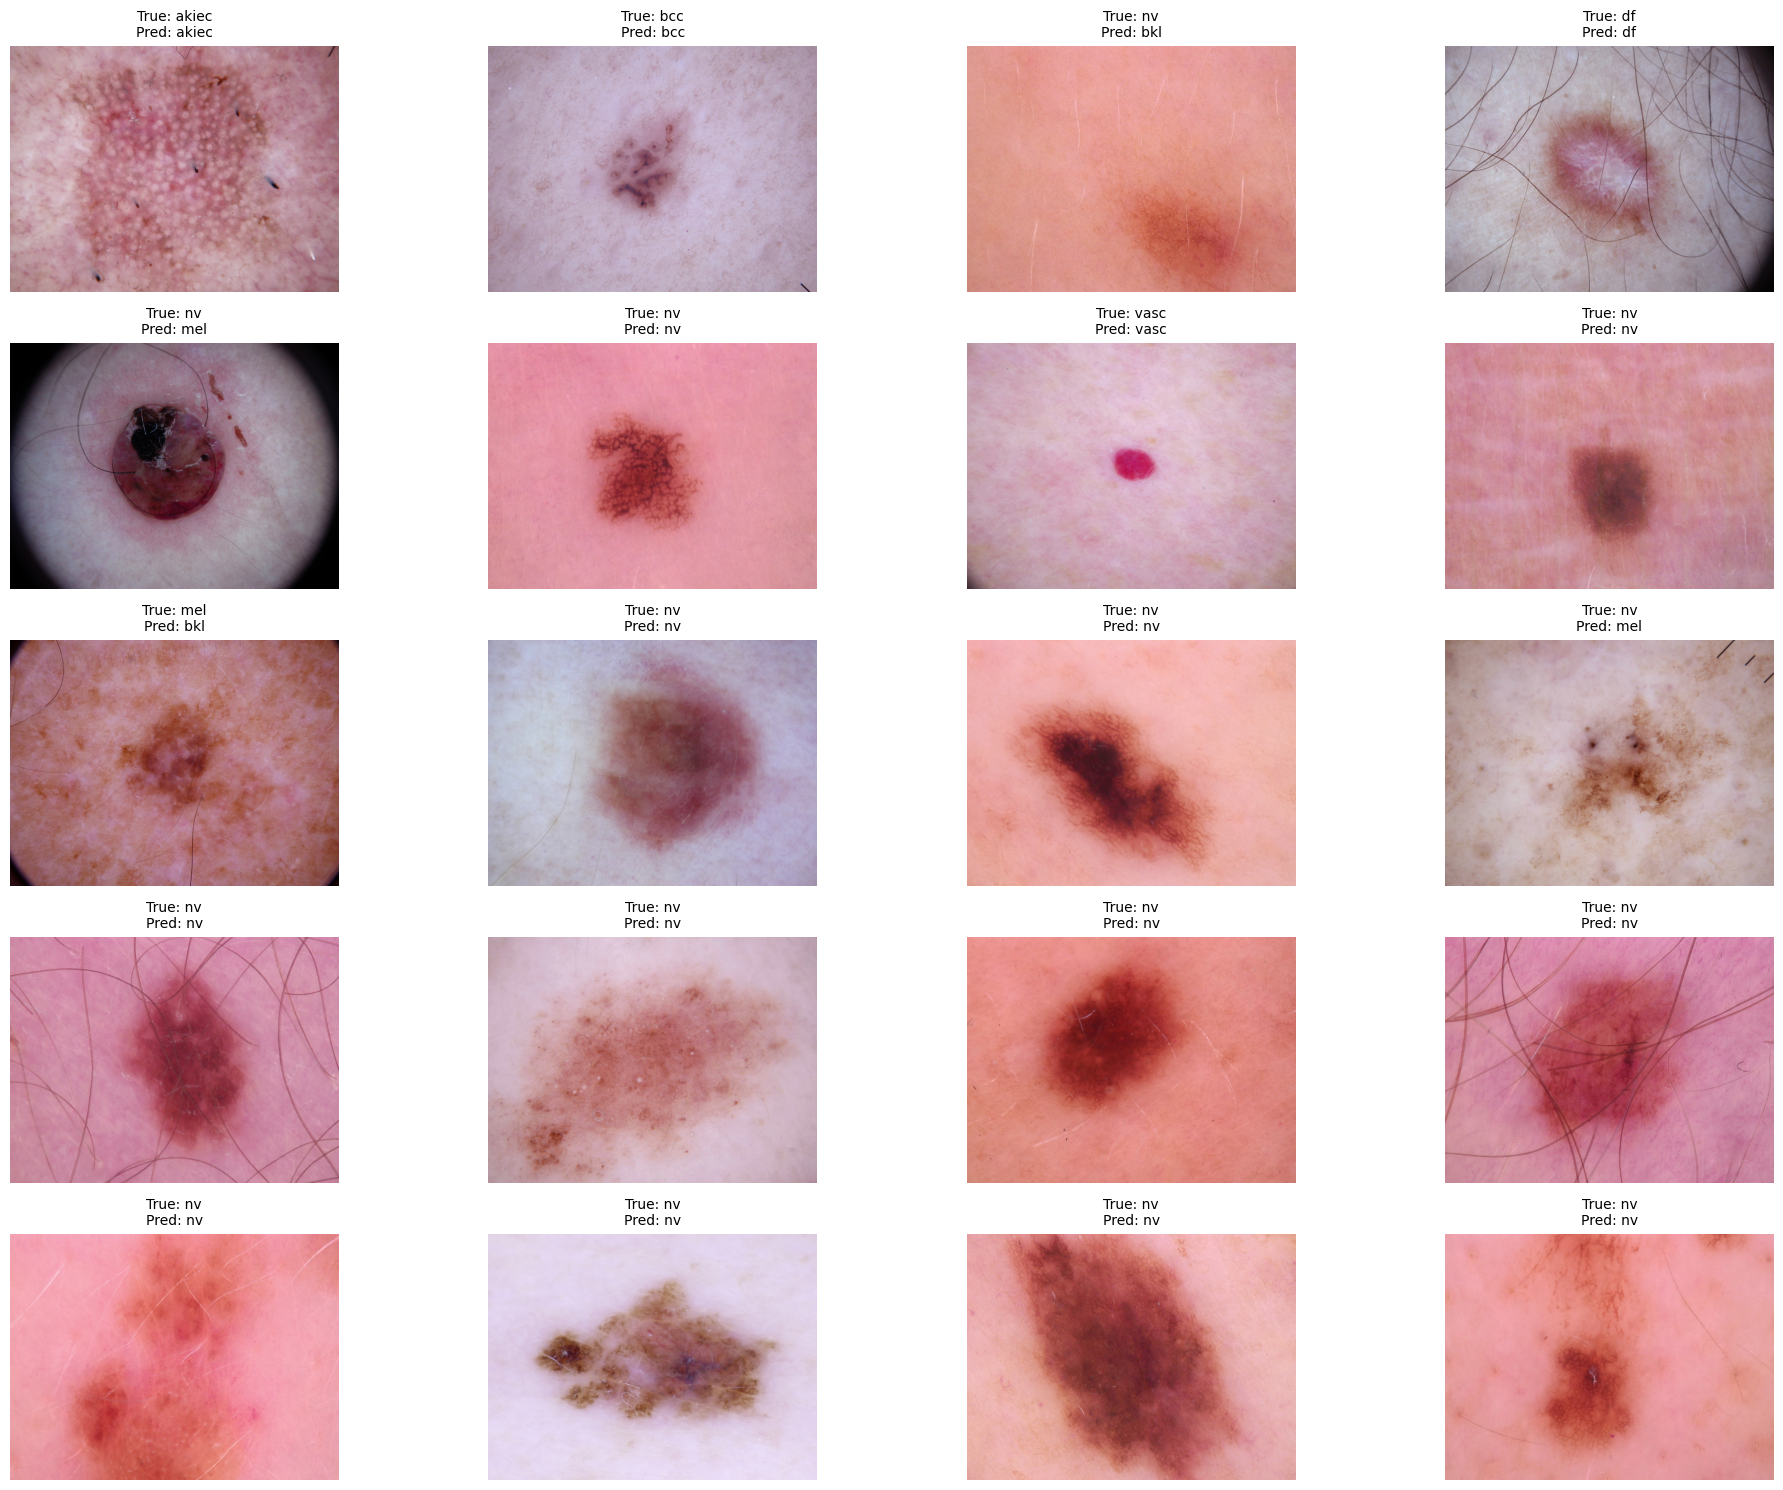

In [27]:
import random
import os
from PIL import Image
import matplotlib.pyplot as plt
from collections import defaultdict

files = test_generator.filenames
y_true_labels = y_true
y_pred_labels = y_pred

label_names = le.classes_
pred_class_indices = defaultdict(list)

for idx, pred in enumerate(y_pred_labels):
    pred_name = le.inverse_transform([pred])[0]
    pred_class_indices[pred_name].append(idx)

chosen_indices = []
for name in label_names:
    indices = pred_class_indices[name]
    if indices:
        chosen_indices.append(random.choice(indices))

extra = list(set(range(len(files))) - set(chosen_indices))
if len(chosen_indices) < 20:
    chosen_indices += random.sample(extra, min(20 - len(chosen_indices), len(extra)))

# Plot in a 5x4 grid
fig, axes = plt.subplots(5, 4, figsize=(20, 15))
axes = axes.flatten()

for ax, idx in zip(axes, chosen_indices):
    img_path = os.path.join(test_generator.directory, files[idx])
    true_name = le.inverse_transform([y_true_labels[idx]])[0]
    pred_name = le.inverse_transform([y_pred_labels[idx]])[0]

    img = Image.open(img_path)
    ax.imshow(img)
    ax.axis('off')
    ax.set_title(f"True: {true_name}\nPred: {pred_name}", fontsize=10)

plt.tight_layout()
plt.show()
